<a href="https://colab.research.google.com/github/okana2ki/multiV/blob/main/kmeans_SSDSE_C_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習帳：[非階層的クラスタリング](https://colab.research.google.com/github/chokkan/mlnote/blob/main/unsupervised/01kmeans.ipynb) より

## 確認問題

[教育用標準データセット（SSDSE）](https://www.nstac.go.jp/SSDSE/)に収録されている都道府県庁所在市別・家計消費データ（SSDSE-C）に対してクラスタ分析を適用し、消費行動が類似している都道府県のクラスタを作りたい。

### (1) データセットの読み込み

このデータセットを読み込み、各都道府県庁所在地を特徴ベクトルで表現せよ。

In [5]:
# prompt: https://www.nstac.go.jp/sys/files/SSDSE-C-2026.csv を読み込み、先頭5行を表示

import pandas as pd

url = 'https://www.nstac.go.jp/files/SSDSE-C-2026.csv'
# サーバーによるブロックを回避するため、User-Agentを指定します
storage_options = {'User-Agent': 'Mozilla/5.0'}
df = pd.read_csv(url, encoding='shift_jis', storage_options=storage_options)
df.head()

,SSDSE-C-2026,2023-2025年,City,LA03,LB00,LB01,LB011001,LB012001,LB012002,LB013001,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
0,地域コード,都道府県,市,世帯人員,食料（合計）,01 穀類,米,食パン,他のパン,生うどん・そば,...,すし（外食）,和食,中華食,洋食,焼肉,ハンバーガー,他の主食的外食,喫茶代,飲酒代,学校給食
1,R00000,全国,全国,2.88,1085539,91820,30111,10713,23530,3777,...,16577,26615,5121,13378,8444,6446,54738,10261,18073,7756
2,R01100,北海道,札幌市,2.77,1007628,91994,35984,9366,19957,3515,...,17303,23714,3580,18638,8162,4823,26979,7456,21073,12205
3,R02201,青森県,青森市,2.79,1010524,87921,29339,9621,19671,3387,...,14942,16945,3117,9401,7194,4529,20519,4626,11361,1247
4,R03201,岩手県,盛岡市,2.85,1042728,86816,28660,8716,20144,3730,...,14794,14403,2200,7384,7674,4926,47895,7112,20520,10972


* ダウンロードしてきたファイルを読み込んでもよいのですが、今回は、サイトから直接ファイルを読み込むことにしました。
* 最近、SSDSEのサーバーの仕様が変わり、プログラムからのダウンロードがブロックされるようになったので、それに対処できるコードにしてあります。
* いきなり、特徴ベクトル表現をしてもよいのですが、**まず、読み込むだけ**、というように**小分けに指示**して、**内容を確認しながら**進むことにしました。**複雑なプログラムを作るときは、段階を踏んで作っていく方がお勧め**です。（AIの能力が急速に高まりつつあるので、複雑なプログラムを一気に作れるようになる方向にはありますが）
* 今回のような依頼の仕方をすると、shift_jisであることは、AIが適切に判断してくれることが多いようです。shift_jisで読み込まなかった場合は、エラーが出ますが、エラーをAIに説明してもらったり対処してもらうのは容易でしょう。
* **ここで読み込んだ内容を確認しておく**と、この後、特徴ベクトルを抽出したときに、うまくできているかの確認が容易です。




In [6]:
# prompt: 各都道府県庁所在地（2行目以降）を特徴ベクトル（4列目以降）で表現し、先頭5行を表示

# 各都道府県庁所在地（2行目以降）を特徴ベクトル（4列目以降）で表現
df_features = df.iloc[2:, 4:]

# 先頭5行を表示
df_features.head()


,LB00,LB01,LB011001,LB012001,LB012002,LB013001,LB013002,LB013003,LB013004,LB013005,...,LB121104,LB121105,LB121106,LB121107,LB121108,LB121109,LB121110,LB121201,LB121202,LB122001
2,1007628,91994,35984,9366,19957,3515,2057,1558,4663,6428,...,17303,23714,3580,18638,8162,4823,26979,7456,21073,12205
3,1010524,87921,29339,9621,19671,3387,2771,1288,6192,8326,...,14942,16945,3117,9401,7194,4529,20519,4626,11361,1247
4,1042728,86816,28660,8716,20144,3730,2603,1423,6475,7023,...,14794,14403,2200,7384,7674,4926,47895,7112,20520,10972
5,1065052,86729,26933,10030,21414,3400,2138,1616,5185,7189,...,17554,28348,3858,14261,7886,6238,24913,10027,20529,10741
6,1030621,82086,24802,8532,18253,3828,3943,1361,6331,7215,...,16134,19689,2598,8868,8536,4181,25919,6027,16841,13111


* **2行目以降という指示**なしに自動で判断させることは難しいようでした。1行目の全国を除こうと思ったので、こうしました。なお、0行目から始まるので、その数え方で指示しましたが、1行目から始まる数え方で指示してもAIが判断してくれることもあると思います。

* **4列目以降**というのを指示なしで自動判断するのも難しいようです。食料（合計）の列以降、というつもりです。**「消費行動の類似性でクラスタリングせよ」というお題**なので、「世帯人員」列を除くのは妥当だと思います。「食料（合計）」は、それ以降の列の合計なので、冗長な特徴になっていると思われるので、これも除くという考えもあると思います。また、「穀類」のような小計の列もあり、これも除いた方がよいかもしれませんが、どの列を除くかの指示が面倒かなと思い、小計も合計も含まれたままにしました。（実は、これが後で問題になります）（後で紹介しますが、実は、ある方法を使うと、小計や合計の列は簡単に除くことができます）

* 丁寧に分析するなら、「世帯人員」で、各品目の支出額を正規化するという分析が望ましいかを検討すべきですが、今回はそれはしていません。各品目の支出額は一世帯当たりで集計されているので、それで正規化した方が消費の特徴を表しているとも言えるし、世帯人数の多少も含めて支出額の特徴を捉えるという考えもあると思います。

* 各品目の支出額は一世帯当たりで集計されている、というようなことは、[SSDSEのHP](https://www.nstac.go.jp/use/literacy/ssdse/)の[**データごとの解説資料**](https://www.nstac.go.jp/sys/files/kaisetsu-C-2026.pdf)に書いてあります。**適切な分析のためには、分析前に解説に目を通しておくことが必要**ですね。

* ここで**抽出した結果を表示して、意図通りにできていることを確認**して、次に進みます。

* 元のデータの0行目の品目名や、2列目の都市名がdf_featuresには含まれておらず、分かりにくくなっているのですが、必要になれば、後で回復できるはずなので、ここはそのままにして進みます。

### (2) WCSSのプロット

K-meansクラスタリングを異なるクラスタ数$K$で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

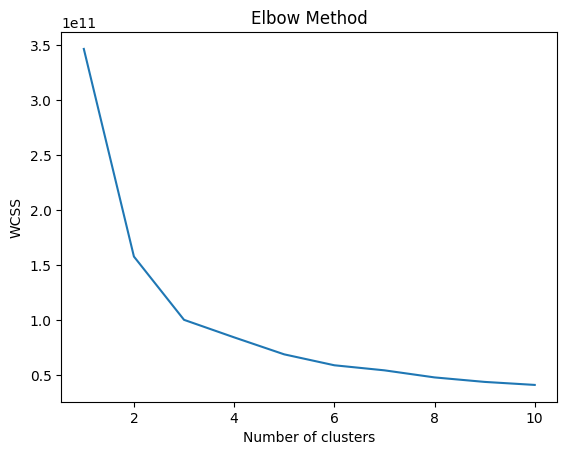

In [7]:
# prompt: K-meansクラスタリングを異なるクラスタ数 K で実行し、横軸にクラスタ数、縦軸にK-meansの目的関数の値、すなわちクラスタ内平方和（WCSS: within-cluster sum-of-squares）をプロットしたグラフを描画せよ。

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# クラスタ数の上限
max_clusters = 10

# クラスタ数ごとのWCSSを格納するリスト
wcss = []

# 異なるクラスタ数でK-meansクラスタリングを実行
for i in range(1, max_clusters + 1):
  kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)  # n_init: 初期化回数（何回試すか）を明示的に指定することで警告メッセージを回避
  kmeans.fit(df_features)

  # クラスタ内平方和（WCSS）をリストに追加
  wcss.append(kmeans.inertia_)

# クラスタ数とWCSSをプロット
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


↑このグラフが何のことか分からない人は、[この資料](https://colab.research.google.com/github/chokkan/mlnote/blob/main/unsupervised/01kmeans.ipynb)の目次から「クラスタ数の選び方」を参照。

* 以上のように、問題文をそのままプロンプトに入力すると、うまくプログラミングできた！と一瞬喜んでしまうかもしれませんが、ここで、落ち着いて、データを見直してみましょう。

* すると、**品目によって、支出額の多少に開きがある**のはもちろん、小計や合計もあるので、**特に一番大きい「食料（合計）」という特徴量が大きく効いて**、**ほぼ「食料（合計）」の多少だけでクラスタリングが決まってしまっているのではないか**と想像できます。

* これでは、題意であった「消費行動の類似性」によりクラスタリングしたことにはなっていませんよね。ほぼ合計額だけを考慮してクラスタリングしたことになってしまっていると思います。

* このような結果になってしまっていることをちゃんとデータで確認するには、このまま次の(3)に進んで、各クラスタに属する都市名を洗い出すか、または、**クラスタごとの「食料（合計）」の箱ひげ図**を描くと、確認できると思います。ぜひ、この確認にチャレンジしてみて下さい。**←今日の宿題その１**

* さて、この「大きな値の特徴量にクラスタリング結果が左右されてしまう」という問題は、どう対処したらよいでしょうか？

* まずやるべきことは、**小計や合計をデータから除く**ことです。**←今日の宿題その２**。これは「消費行動の類似性」によりクラスタリングするという目的から考えると、必要な操作だと思います。ただ、ちょっと、除くための指示が面倒そうに思うかもしれません。

* 合計や小計をデータから除くのは、個別にこの列を除けと指示しなくても、一括指示することができそうです。どうしてかというと、一番上の行（各列の識別記号）を見ると、合計や小計は、LB00やLB01のような短かいコードが割り振られているからです。AIと相談すると具体的にどうすればよいかを教えてくれると思います。さらにいうと、データの形式を説明するPDFファイルを添付してAIに頼むとより確実にやりたいことが伝わります。なお、ただし、合計や小計も特徴量だと捉えてクラスタリングするという考えもありかなとも思います。

* 続いてやるべきことは、**データを前処理してから、クラスタリング**を行うことです。この前処理は、上記にしたがって、個別の品目の支出額だけを残したデータとした場合も、それらの支出額の間に大き目の開きがあるので、有効に働くと思いますし、合計や小計を残したまま分析するときは必須となります。

* どのような前処理をするとよいか、ぜひ考えて、それを実行してみて下さい。その後、クラスタリングを実行して、結果を前処理しなかった場合と比べて下さい。**←今日の宿題その３**。AIに質問しても、おそらく正しい前処理を教えてくれると思います。前回、すでに、この前処理が加えられていた人も、AIの判断で自動で加えられたのであれば、なぜそれが必要なのかが、「今日の宿題その1」で分かったと思います。

* 前処理のヒントを書いておくと、「標準化」です。「標準化」と「正規化」については、[ここ](https://qiita.com/oki_kosuke/items/02ec7bee92c85cf10ac2)を参照して**内容やそれをする理由を理解してから**、プログラムを書いて実行して下さい。キーワードだけ聞いて、AIにプログラムを頼んでおしまい、では力がつきません。AIに理由とかも尋ねながらプログラミングするという勉強スタイルであれば、それでいいのですが。

### (3) K-meansクラスタリング

(2)の結果に基づき、クラスタ数$K$を適当に選び、K-meansクラスタリングを実行せよ。$1$から$K$までの各クラスタに対して、それぞれ所属する都道府県庁所在地を明らかにせよ。**←今日の宿題その４**

## 演習問題（今日の宿題その５）

以上のデータ（合計や小計を除いて、標準化したもの）を、階層的クラスタリングしなさい（デンドログラムを書きなさい）